# Sentiment Analysis of Book Reviews using RNN, LSTM, and Word2Vec Embeddings
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Assessment:** Part III – Natural Language Processing Task  
**Institution:** Herald College, Kathmandu  
**Date:** April 2026

---

---
## 0. Install Dependencies
Run this cell **once** at the start of every Colab session. Restart runtime if prompted after numpy downgrade.

In [2]:
# Install required libraries
!pip install numpy -q
!pip install gensim -q
!pip install gradio -q
!pip install wordcloud -q
!pip install nltk -q
!pip install contractions -q
print("All packages installed. Restart runtime if numpy was downgraded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
All packages installed. Restart runtime if numpy was downgraded.


---
## 1. Mount Google Drive & Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
import time
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

# Contractions
import contractions

# Scikit-learn
from sklearn.model_selection    import train_test_split
from sklearn.metrics            import (accuracy_score,
                                        confusion_matrix,
                                        classification_report,
                                        ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Word cloud
from wordcloud import WordCloud

# TensorFlow / Keras
import tensorflow as tf
try:
    from tensorflow.keras.preprocessing.text     import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
except ImportError:  # TF 2.16+ moved these to keras legacy
    from keras.src.legacy.preprocessing.text     import Tokenizer
    from keras.src.legacy.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import (Embedding, SimpleRNN,
                                                      LSTM, Bidirectional,
                                                      Dense, Dropout)
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers             import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version :", tf.__version__)
print("NumPy version      :", np.__version__)
print("All libraries imported successfully.")

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
All libraries imported successfully.


---
## 2. Load and Explore the Dataset

In [ ]:
# ── Adjust this path to where your CSV lives in Google Drive ──────────────────
DATA_PATH = '/content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample/Book_review.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH)

# Drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("Dataset shape  :", df.shape)
print("Columns        :", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset shape  : (12000, 3)
Columns        : ['rating', 'reviewText', 'summary']

First 5 rows:


,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total records  : {len(df)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

DATASET OVERVIEW
Total records  : 12000

Missing values:
rating        0
reviewText    0
summary       2
dtype: int64

Data types:
rating         int64
reviewText    object
summary       object
dtype: object

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


In [ ]:
# Drop rows where reviewText is missing
df.dropna(subset=['reviewText'], inplace=True)
df.reset_index(drop=True, inplace=True)
print("Records after dropping nulls:", len(df))

Records after dropping nulls: 12000


### 2.1 Map Ratings → Sentiment Labels

| Rating | Sentiment | Label |
|--------|-----------|-------|
| 1 – 2  | Negative  | 0     |
| 3      | Neutral   | 1     |
| 4 – 5  | Positive  | 2     |

In [ ]:
def map_sentiment(rating: int) -> int:
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['sentiment'] = df['rating'].apply(map_sentiment)

# map_sentiment already produces clean {0, 1, 2} — LabelEncoder not needed.
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
NUM_CLASSES  = len(label_names)

print("Unique labels  :", np.unique(df['sentiment']))   # must be [0 1 2]
print("\nSentiment distribution:")
print(df['sentiment'].value_counts().rename(label_names).sort_index())

Unique labels  : [0 1 2]

Sentiment distribution:
sentiment
Negative    4000
Neutral     2000
Positive    6000
Name: count, dtype: int64


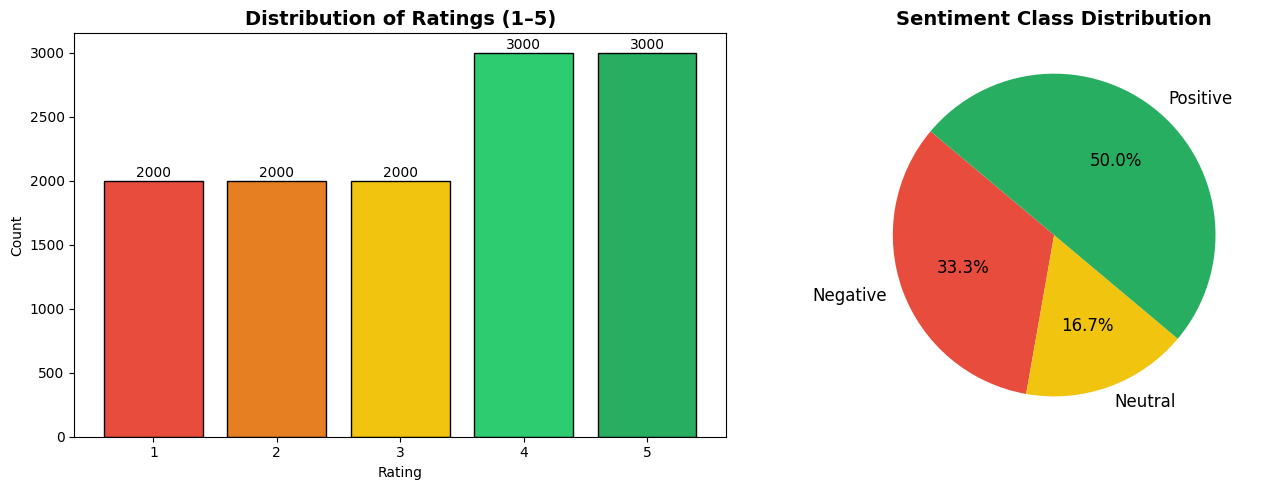

Figure saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating bar chart
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
            edgecolor='black')
axes[0].set_title('Distribution of Ratings (1–5)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 30, str(v), ha='center', fontsize=10)

# Sentiment pie chart
sentiment_counts = df['sentiment'].value_counts().sort_index()  # sort by label 0=Neg,1=Neu,2=Pos
axes[1].pie(sentiment_counts.values,
            labels=[label_names[i] for i in sentiment_counts.index],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#f1c40f', '#27ae60'],  # red=Negative, yellow=Neutral, green=Positive
            startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

---
## 3. Text Preprocessing

In [ ]:
# Keep sentiment-bearing / negation words out of the stopword list
# so the model does not lose context like "not good" or "never boring"
FULL_STOP_WORDS = set(stopwords.words('english'))
KEEP_WORDS      = {'not','no','never','nor','neither','without',
                   'very','too','only','but','however','although'}
STOP_WORDS      = FULL_STOP_WORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a raw review string."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions  ("don't" → "do not")
    text = contractions.fix(text)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove @mentions and #hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove digits
    text = re.sub(r'\d+', '', text)
    # 6. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 7. Tokenise
    tokens = text.split()
    # 8. Remove stopwords and lemmatise (keep tokens > 1 char)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]

    return ' '.join(tokens)


print("Cleaning text … (may take 1–2 minutes)")
df['clean_text'] = df['reviewText'].apply(clean_text)
print("Done.")

# Before / after example
print("\n--- BEFORE ---")
print(df['reviewText'].iloc[5][:300])
print("\n--- AFTER  ---")
print(df['clean_text'].iloc[5][:300])

Cleaning text … (may take 1–2 minutes)
Done.

--- BEFORE ---
I really enjoyed how this story developed.  Its a well-written Sci-fi depicting what happens when an alien race quietly tries to study earth and one of the members of the scientific team gets away from the group and is discovered by a human.  The world-building of the alien race was easy to follow s

--- AFTER  ---
really enjoyed story developed wellwritten scifi depicting happens alien race quietly try study earth one member scientific team get away group discovered human worldbuilding alien race easy follow since explanation came steadily throughout story instead one long monologue beginningthe character per


In [ ]:
# Drop rows where cleaning produced an empty string
before = len(df)
df     = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty rows. Remaining: {len(df)}")

# Verify
empty = (df['clean_text'].str.strip() == '').sum()
print(f"Empty clean_text rows: {empty}  (should be 0)")

print("\nSample cleaned texts:")
print(df['clean_text'].head(5).to_string())

Dropped 0 empty rows. Remaining: 12000
Empty clean_text rows: 0  (should be 0)

Sample cleaned texts:
0    book very first bookmobile book bought school ...
1    read description book could not wait read down...
2    edit review book believe got right updated rew...
3    not normally buy mystery novel not like howeve...
4    not kind book normally read although try not l...


### 3.1 Review Length Analysis

In [ ]:
df['review_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print("Review length statistics (words after cleaning):")
print(df['review_length'].describe().round(2))

# Use 95th percentile but enforce minimum of 100 tokens
p95     = int(np.percentile(df['review_length'], 95))
MAX_LEN = max(p95, 100)
print(f"\n95th-percentile : {p95}")
print(f"MAX_LEN used    : {MAX_LEN}")

Review length statistics (words after cleaning):
count    12000.00
mean        56.36
std         65.32
min          1.00
25%         17.00
50%         32.00
75%         69.00
max       1129.00
Name: review_length, dtype: float64

95th-percentile : 187
MAX_LEN used    : 187


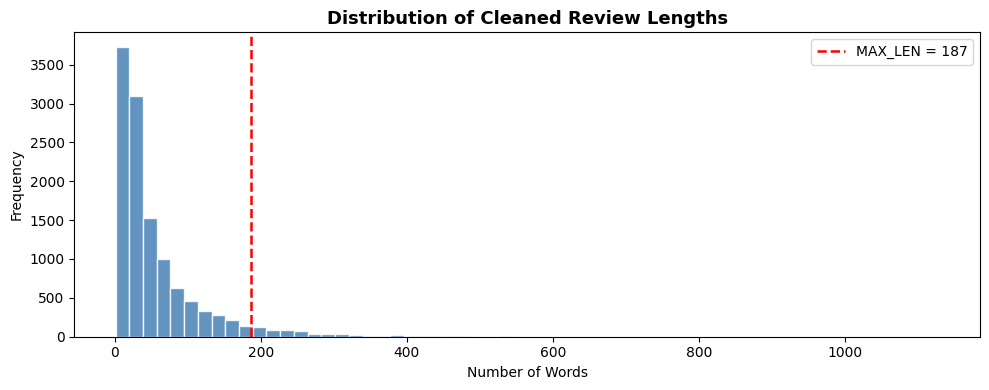

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['review_length'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=1.8,
           label=f'MAX_LEN = {MAX_LEN}')
ax.set_title('Distribution of Cleaned Review Lengths', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Word Cloud Visualisation

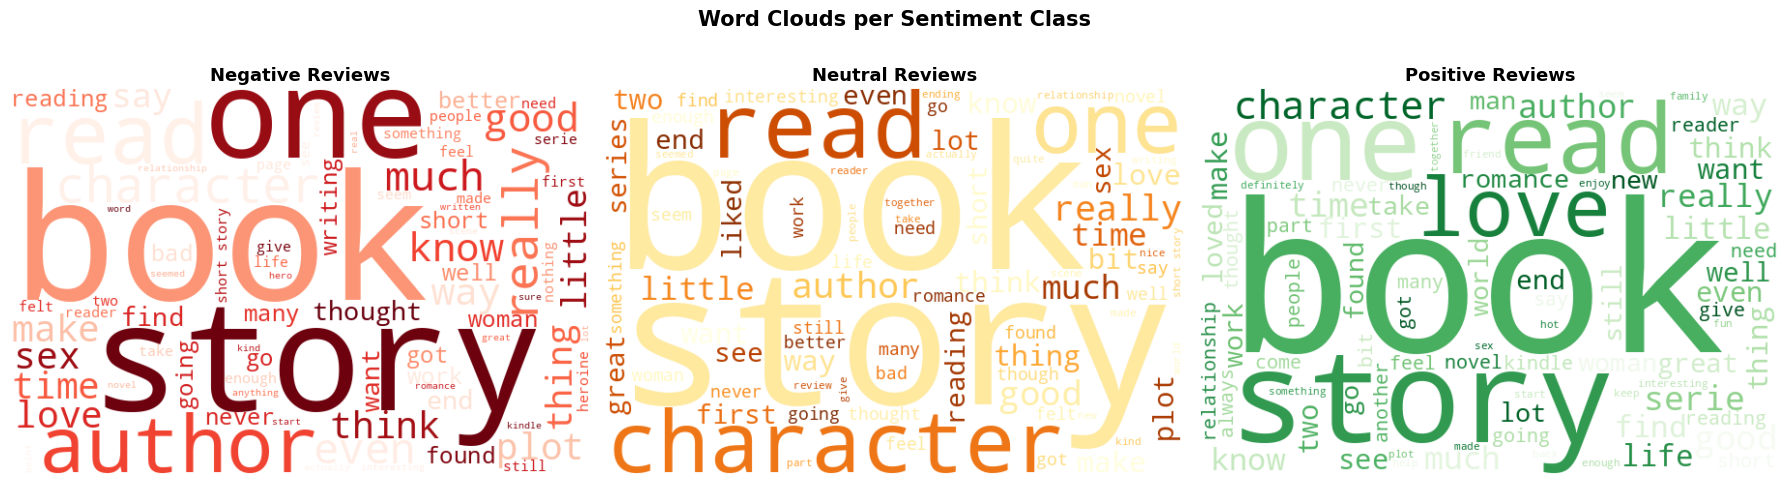

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps     = ['Reds', 'YlOrBr', 'Greens']

for ax, sent, cmap in zip(axes, [0, 1, 2], cmaps):
    corpus = ' '.join(df[df['sentiment'] == sent]['clean_text'].tolist())
    wc     = WordCloud(width=600, height=400, background_color='white',
                       colormap=cmap, max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label_names[sent]} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds per Sentiment Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Tokenisation, Padding & Train / Validation / Test Split

In [ ]:
# Hyperparameters tuned for stable training and lower overfitting
VOCAB_SIZE = 12000
OOV_TOKEN  = '<OOV>'
EMBED_DIM  = 64

X = df['clean_text'].values
y = df['sentiment'].values.astype(int)

# 70% train, 15% validation, 15% test.
# This is cleaner than validation_split because the test set is kept fully untouched.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

print(f"Train      : {len(X_train_raw)} samples")
print(f"Validation : {len(X_val_raw)} samples")
print(f"Test       : {len(X_test_raw)} samples")

print("\nTrain label distribution (normalised):")
print(pd.Series(y_train).value_counts(normalize=True)
        .rename(label_names).sort_index().round(3))

print("\nValidation label distribution (normalised):")
print(pd.Series(y_val).value_counts(normalize=True)
        .rename(label_names).sort_index().round(3))

print("\nTest label distribution (normalised):")
print(pd.Series(y_test).value_counts(normalize=True)
        .rename(label_names).sort_index().round(3))

Train      : 8400 samples
Validation : 1800 samples
Test       : 1800 samples

Train label distribution (normalised):
Negative    0.333
Neutral     0.167
Positive    0.500
Name: proportion, dtype: float64

Validation label distribution (normalised):
Negative    0.333
Neutral     0.167
Positive    0.500
Name: proportion, dtype: float64

Test label distribution (normalised):
Negative    0.333
Neutral     0.167
Positive    0.500
Name: proportion, dtype: float64


In [ ]:
# Fit tokenizer on TRAINING data only (no data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_raw)

word_index = tokenizer.word_index
print(f"Full vocabulary size  : {len(word_index)}")
print(f"Vocabulary kept (top) : {VOCAB_SIZE}")


def print_oov_rate(name, texts):
    seqs = tokenizer.texts_to_sequences(texts)
    total_tok = sum(len(s) for s in seqs)
    oov_tok = sum(s.count(1) for s in seqs)  # index 1 = <OOV>
    rate = (oov_tok / total_tok * 100) if total_tok else 0
    print(f"{name} OOV rate      : {rate:.1f}%")

print()
print_oov_rate('Validation', X_val_raw)
print_oov_rate('Test', X_test_raw)

Full vocabulary size  : 33347
Vocabulary kept (top) : 12000

Validation OOV rate      : 6.5%
Test OOV rate      : 6.7%


In [ ]:
# Convert to padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_val_seq   = tokenizer.texts_to_sequences(X_val_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                            padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN,
                            padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                            padding='post', truncating='post')

print("X_train_pad shape :", X_train_pad.shape)
print("X_val_pad shape   :", X_val_pad.shape)
print("X_test_pad shape  :", X_test_pad.shape)
print("y_train sample    :", y_train[:8])
print("y_val sample      :", y_val[:8])
print("y_test sample     :", y_test[:8])

X_train_pad shape : (8400, 187)
X_val_pad shape   : (1800, 187)
X_test_pad shape  : (1800, 187)
y_train sample    : [1 2 2 2 2 2 1 0]
y_val sample      : [2 2 2 2 2 2 0 2]
y_test sample     : [1 2 2 0 0 2 0 2]


In [ ]:
# Class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:",
      {label_names[k]: round(v, 3) for k, v in class_weight_dict.items()})

Class weights: {'Negative': np.float64(1.0), 'Neutral': np.float64(2.0), 'Positive': np.float64(0.667)}


---
## 5. Helper Functions

In [ ]:
def plot_history(history, model_name: str):
    """Plot training vs. validation loss and accuracy with overfitting annotation."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']
    train_acc  = history.history['accuracy']
    val_acc    = history.history['val_accuracy']
    epochs_ran = range(len(train_loss))

    # Loss plot
    axes[0].plot(epochs_ran, train_loss, color='royalblue', linewidth=2, label='Train Loss')
    axes[0].plot(epochs_ran, val_loss,   color='tomato', linestyle='--', linewidth=2, label='Val Loss')
    axes[0].fill_between(epochs_ran, train_loss, val_loss,
                         alpha=0.08, color='tomato', label='Gap')
    axes[0].set_title(f'{model_name} - Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    axes[1].plot(epochs_ran, train_acc, color='royalblue', linewidth=2, label='Train Acc')
    axes[1].plot(epochs_ran, val_acc,   color='tomato', linestyle='--', linewidth=2, label='Val Acc')
    axes[1].fill_between(epochs_ran, train_acc, val_acc,
                         alpha=0.08, color='tomato', label='Gap')
    # Annotate best val accuracy
    best_val_epoch = int(np.argmax(val_acc))
    best_val       = val_acc[best_val_epoch]
    axes[1].annotate(f'Best val: {best_val:.2%}',
                     xy=(best_val_epoch, best_val),
                     xytext=(best_val_epoch + 0.5, best_val - 0.04),
                     fontsize=9, color='tomato',
                     arrowprops=dict(arrowstyle='->', color='tomato', lw=1.2))
    axes[1].set_title(f'{model_name} - Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Overfitting summary in suptitle
    final_gap = abs(train_acc[-1] - val_acc[-1])
    gap_label = 'Healthy' if final_gap < 0.05 else ('Mild overfit' if final_gap < 0.12 else 'Overfit')
    fig.suptitle(f'{model_name}  |  Best Val Acc: {best_val:.2%}  |  Train/Val gap: {final_gap:.2%} ({gap_label})',
                 fontsize=11, color='#444', y=1.02)

    plt.tight_layout()
    fname = re.sub(r'[^a-z0-9]+', '_', model_name.lower()).strip('_') + '_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test_pad, y_test_int, model_name: str):
    """Print accuracy, prediction distribution, classification report,
       and confusion matrix for a given model."""

    y_pred_proba = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    unique, counts = np.unique(y_pred, return_counts=True)
    dist = {label_names[u]: int(c) for u, c in zip(unique, counts)}
    print(f"\nPrediction distribution : {dist}")
    if len(unique) == 1:
        print("WARNING: model is predicting only ONE class - check training.")

    acc = accuracy_score(y_test_int, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name} - Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*55}")
    print("\nClassification Report:")
    print(classification_report(y_test_int, y_pred,
                                 target_names=list(label_names.values())))

    cm   = confusion_matrix(y_test_int, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=list(label_names.values()))
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} - Confusion Matrix',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = re.sub(r'[^a-z0-9]+', '_', model_name.lower()).strip('_') + '_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred


def get_callbacks():
    """Default callbacks for Models 1 and 3."""
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]


print("Helper functions defined.")

Helper functions defined.


---
## 6. Model 1 – Simple RNN with Trainable Embedding

> **Architecture Rationale:**  
> A Simple RNN processes sequences step-by-step, making it a lightweight baseline. However,
> it is inherently prone to the **vanishing gradient problem** — gradients shrink exponentially
> as they propagate back through long sequences, making it difficult to learn long-range
> dependencies. A high learning rate amplifies this instability rather than causing it, so
> the fix here is `clipnorm=1.0` (gradient clipping) combined with a conservative
> `learning_rate=0.0003`.
>
> **Embedding:** Initialised randomly and updated during training (trainable). This gives
> the model full flexibility but requires more data and careful regularisation.
>
> **Dropout:** The RNN layer uses `dropout=0.25` (input) and `recurrent_dropout=0.15` (recurrent
> connections) to prevent co-adaptation. The dense layers use `Dropout(0.5)` and `Dropout(0.4)`
> respectively — higher rates are applied there because the dense layers are most prone to
> memorisation on small datasets.
>
> **Epochs = 25 with EarlyStopping:** Setting a generous ceiling of 25 epochs allows the
> model sufficient time to converge, while EarlyStopping (patience=3) halts training
> automatically when validation loss stops improving — preventing over-training without
> manual tuning.
>
> **Overfitting note:** The primary causes are high model capacity relative to the dataset
> and the fact that embeddings are trained from scratch (random initialisation encourages
> memorisation). Learning rate plays a secondary role by controlling the speed of
> memorisation, not its root cause.


In [ ]:
tf.keras.backend.clear_session()
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, mask_zero=True,
              embeddings_regularizer=tf.keras.regularizers.l2(1e-5),  # NEW: regularise embeddings
              name='embedding_rnn'),
    tf.keras.layers.SpatialDropout1D(0.37, name='spatial_dropout'),
    SimpleRNN(48,
              return_sequences=False,
              dropout=0.27,
              recurrent_dropout=0.13,
              kernel_regularizer=tf.keras.regularizers.l2(1.2e-4),
              recurrent_regularizer=tf.keras.regularizers.l2(1.2e-4),
              name='simple_rnn'),
    Dropout(0.55, name='dropout_1'),
    Dense(16, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-3),
          name='dense_1'),
    Dropout(0.45, name='dropout_2'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='SimpleRNN_Model')

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 1 - Simple RNN ...")
t0 = time.time()

rnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,    # reduced 4→3: stop at epoch ~13-14
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4,
                      patience=1, min_lr=1e-6, verbose=1)  # patience 2→1: react faster
]

rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=rnn_callbacks,
    verbose=1
)

rnn_train_time = time.time() - t0
print(f"\nTraining time: {rnn_train_time:.1f} s")

Training Model 1 - Simple RNN ...
Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.3313 - loss: 1.2149 - val_accuracy: 0.3794 - val_loss: 1.1331 - learning_rate: 5.0000e-04
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.3355 - loss: 1.1837 - val_accuracy: 0.4022 - val_loss: 1.1314 - learning_rate: 5.0000e-04
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3487 - loss: 1.1533
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.3514 - loss: 1.1531 - val_accuracy: 0.3983 - val_loss: 1.1316 - learning_rate: 5.0000e-04
Epoch 4/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.3565 - loss: 1.1487 - val_accuracy: 0.4111 - val_loss: 1.1309 - learning_rate: 2.0000e-04
Epoch 5/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.3548 - loss: 1.1425 - val_accuracy: 0.4633 - val_loss: 1.1272 - learning_rate: 2.0000e-04
Epoch 6/30
132/132

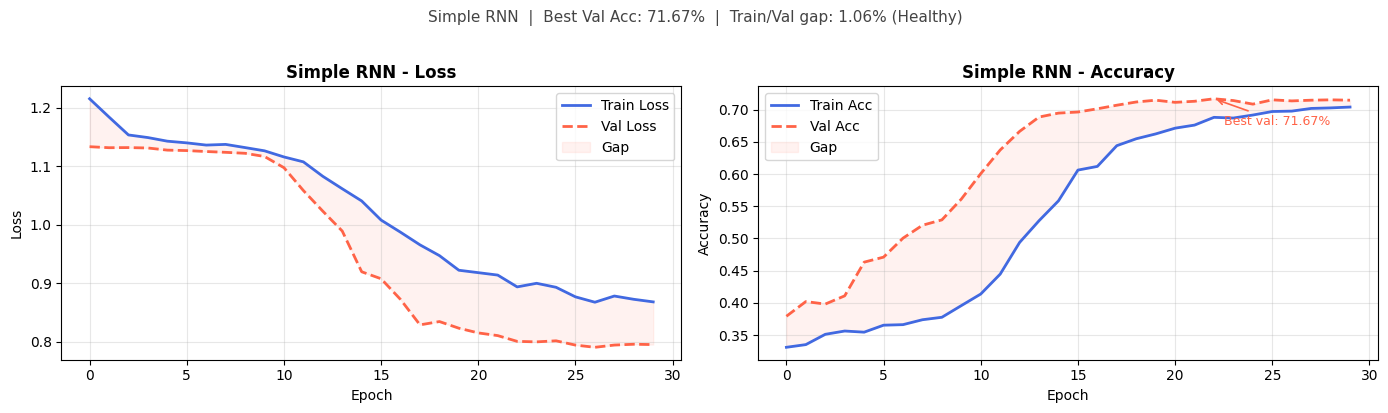


Prediction distribution : {'Negative': 734, 'Neutral': 73, 'Positive': 993}

  Simple RNN - Test Accuracy: 71.33%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.84      0.75       600
     Neutral       0.22      0.05      0.09       300
    Positive       0.77      0.85      0.81       900

    accuracy                           0.71      1800
   macro avg       0.56      0.58      0.55      1800
weighted avg       0.65      0.71      0.67      1800



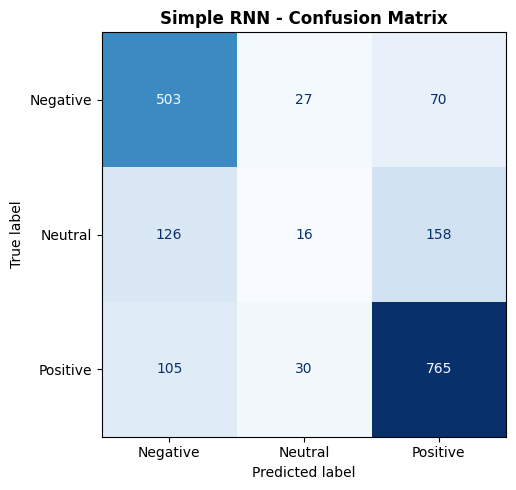

In [ ]:
plot_history(rnn_history, 'Simple RNN')
rnn_acc, rnn_preds = evaluate_model(rnn_model, X_test_pad, y_test, 'Simple RNN')

---
## 7. Model 2 - BiLSTM with Trainable Embedding

> **Architecture Rationale:**  
> The BiLSTM (Bidirectional LSTM) reads sequences in both forward and backward directions,
> giving it a richer contextual view than a simple RNN. This is especially useful for sentiment
> analysis where negation (e.g., "not good") or context at the end of a review affects meaning.
>
> **Improvements over previous version:**  
> The original model showed overfitting — training accuracy climbed to ~84% while validation
> accuracy stalled at ~70%. The following changes address this:
>
> - **`SpatialDropout1D(0.4)`** after the Embedding layer drops entire feature maps (channels),
>   more effective than standard dropout for sequential/NLP models since it breaks correlation
>   across timesteps rather than just individual activations.
> - **Increased LSTM dropout to 0.50** (from 0.45) and **recurrent_dropout to 0.25** (from 0.15)
>   to constrain memorisation further inside the recurrent computation.
> - **Stronger L2 regularisation (5e-4)** on all kernel weights to penalise large weight values.
> - **`BatchNormalization`** after the dense layer stabilises activations and acts as an
>   implicit regulariser, reducing the gap between train and val performance.
> - **Reduced Dense units to 16** (from 32) to lower total capacity and limit overfitting.
> - **`EarlyStopping patience=4`** (instead of 3) allows slightly more training time before
>   halting, so the model does not stop prematurely in flat val_loss regions.
> - **`ReduceLROnPlateau patience=2`** (instead of 1) reduces jitter from too-frequent LR drops.


In [ ]:
tf.keras.backend.clear_session()
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, mask_zero=True,
              embeddings_regularizer=tf.keras.regularizers.l2(1e-5),  # regularise embeddings
              name='embedding_bilstm'),
    tf.keras.layers.SpatialDropout1D(0.40, name='spatial_dropout'),   # increased 0.30→0.40
    Bidirectional(LSTM(32, return_sequences=False,
                       dropout=0.50,
                       recurrent_dropout=0.30,                         # increased 0.20→0.30
                       kernel_regularizer=tf.keras.regularizers.l2(5e-4),
                       recurrent_regularizer=tf.keras.regularizers.l2(5e-4)),
                  name='bilstm'),
    Dense(16, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-3),          # stronger 5e-4→1e-3
          name='dense_1'),
    Dropout(0.50, name='dropout_1'),                                   # increased 0.40→0.50
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiLSTM_Trainable')

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "BiLSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_bilstm (Embedding)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 2 - BiLSTM (Trainable Embedding) ...")
t0 = time.time()

bilstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4,   # stronger drop 0.5→0.4
                      patience=1, min_lr=1e-6, verbose=1)  # react faster: patience 2→1
]

lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=25,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=bilstm_callbacks,
    verbose=1
)

lstm_train_time = time.time() - t0
print(f"\nTraining time: {lstm_train_time:.1f} s")

Training Model 2 - BiLSTM (Trainable Embedding) ...
Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 76s 474ms/step - accuracy: 0.4157 - loss: 1.2379 - val_accuracy: 0.4717 - val_loss: 1.2251 - learning_rate: 1.0000e-04
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 79s 455ms/step - accuracy: 0.4213 - loss: 1.2151 - val_accuracy: 0.4878 - val_loss: 1.2033 - learning_rate: 1.0000e-04
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 84s 473ms/step - accuracy: 0.4505 - loss: 1.1942 - val_accuracy: 0.5150 - val_loss: 1.1832 - learning_rate: 1.0000e-04
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 81s 465ms/step - accuracy: 0.5090 - loss: 1.1719 - val_accuracy: 0.6228 - val_loss: 1.1514 - learning_rate: 1.0000e-04
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 81s 455ms/step - accuracy: 0.5754 - loss: 1.1314 - val_accuracy: 0.6717 - val_loss: 1.0743 - learning_rate: 1.0000e-04
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 82s 453ms/step - accuracy: 0.6406 - loss: 1.0595 - val_accuracy: 0.7022 - val_loss: 0.9741 - learning_rate: 1.000

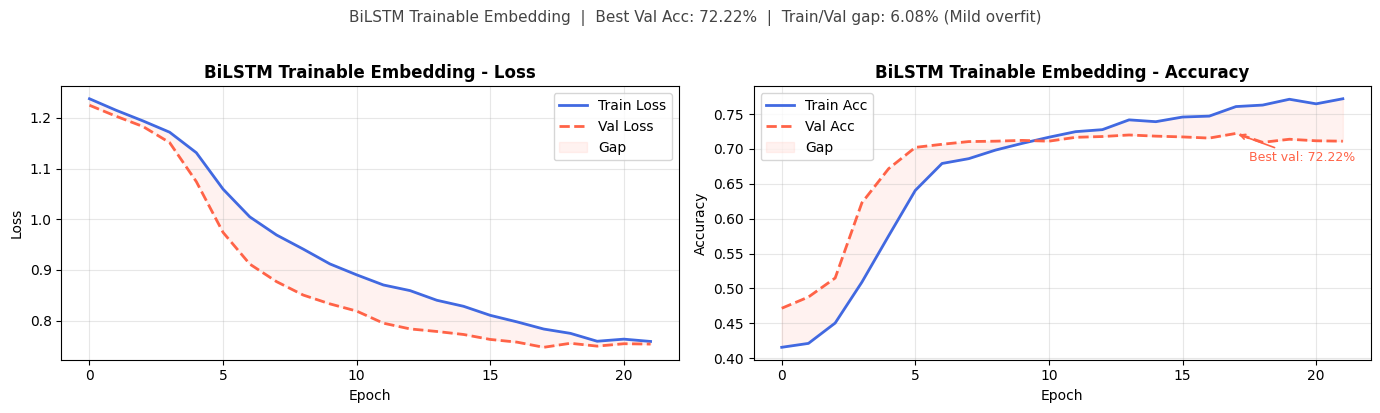


Prediction distribution : {'Negative': 639, 'Neutral': 231, 'Positive': 930}

  BiLSTM Trainable Embedding - Test Accuracy: 72.06%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.79      0.76       600
     Neutral       0.28      0.22      0.24       300
    Positive       0.82      0.84      0.83       900

    accuracy                           0.72      1800
   macro avg       0.61      0.62      0.61      1800
weighted avg       0.70      0.72      0.71      1800



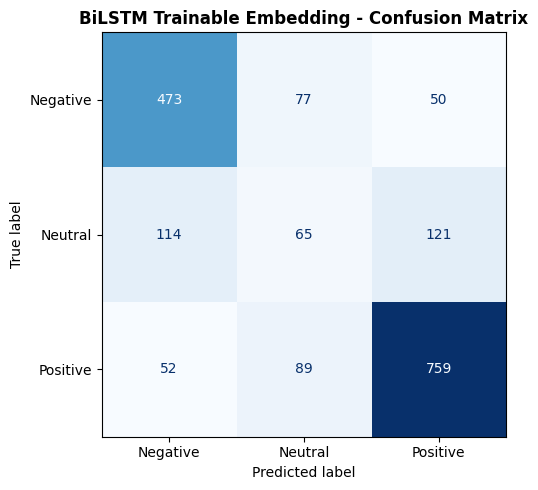

In [ ]:
plot_history(lstm_history, 'BiLSTM Trainable Embedding')
lstm_acc, lstm_preds = evaluate_model(
    lstm_model, X_test_pad, y_test, 'BiLSTM Trainable Embedding')

---
## 8. Model 3 - BiLSTM with Word2Vec Embeddings

Word2Vec is trained only on the training reviews, then used to initialise the embedding layer. This avoids network downloads and aligns with the assignment requirement while still allowing BiLSTM.

In [ ]:
from gensim.models import Word2Vec

WORD2VEC_DIM = 100

# Train Word2Vec on the training split only to avoid test-set leakage.
w2v_sentences = [text.split() for text in X_train_raw]

print("Training Word2Vec embeddings on the training reviews ...")
word2vec_model = Word2Vec(
    sentences=w2v_sentences,
    vector_size=WORD2VEC_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=15,
    seed=42
)

print(f"Word2Vec vocabulary size: {len(word2vec_model.wv.key_to_index)}")

Training Word2Vec embeddings on the training reviews ...
Word2Vec vocabulary size: 14310


In [ ]:
# Build the Word2Vec embedding matrix in tokenizer index order
embedding_matrix = np.random.normal(0, 0.05, (VOCAB_SIZE, WORD2VEC_DIM)).astype(np.float32)
embedding_matrix[0] = np.zeros(WORD2VEC_DIM, dtype=np.float32)  # padding token
hits, misses = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]
        hits += 1
    else:
        misses += 1

total = min(VOCAB_SIZE, len(word_index) + 1)
coverage = hits / max(total - 1, 1) * 100
print(f"Embedding coverage : {hits}/{total - 1} words ({coverage:.1f}%)")
print(f"Missing words      : {misses}")

Embedding coverage : 11998/11999 words (100.0%)
Missing words      : 1


In [ ]:
tf.keras.backend.clear_session()

# BiLSTM + Word2Vec — v2
lstm_word2vec_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=WORD2VEC_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              mask_zero=False,
              trainable=True,
              name='embedding_word2vec'),
    tf.keras.layers.SpatialDropout1D(0.20, name='spatial_dropout'),  # reduced 0.30→0.20
    Bidirectional(LSTM(32, return_sequences=False,
                       dropout=0.30,               # reduced 0.40→0.30
                       recurrent_dropout=0.15,     # reduced 0.20→0.15
                       kernel_regularizer=tf.keras.regularizers.l2(2e-4),   # lighter 5e-4→2e-4
                       recurrent_regularizer=tf.keras.regularizers.l2(2e-4)),
                  name='bilstm'),
    Dense(16, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(2e-4),  # lighter 5e-4→2e-4
          name='dense_1'),
    Dropout(0.35, name='dropout_1'),   # reduced 0.40→0.35
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='BiLSTM_Word2Vec')

lstm_word2vec_model.compile(
    optimizer=Adam(learning_rate=0.0003, clipnorm=1.0),  # increased 0.0001→0.0003
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_word2vec_model.summary()

Model: "BiLSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_word2vec (Embedding)  │ ?                      │     1,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,200,000 (4.58 MB)

 Trainable params: 1,200,000 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 3 - BiLSTM + Word2Vec ...")
t0 = time.time()

w2v_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

lstm_word2vec_history = lstm_word2vec_model.fit(
    X_train_pad, y_train,
    epochs=40,             # increased 25→40: model was still improving at epoch 25
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=w2v_callbacks,
    verbose=1
)

lstm_word2vec_train_time = time.time() - t0
print(f"\nTraining time: {lstm_word2vec_train_time:.1f} s")

Training Model 3 - BiLSTM + Word2Vec ...
Epoch 1/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 474ms/step - accuracy: 0.4043 - loss: 1.1580 - val_accuracy: 0.4811 - val_loss: 1.1343 - learning_rate: 3.0000e-04
Epoch 2/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 77s 438ms/step - accuracy: 0.4296 - loss: 1.1313 - val_accuracy: 0.5711 - val_loss: 1.0804 - learning_rate: 3.0000e-04
Epoch 3/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 56s 420ms/step - accuracy: 0.4920 - loss: 1.0817 - val_accuracy: 0.6578 - val_loss: 0.9618 - learning_rate: 3.0000e-04
Epoch 4/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 82s 421ms/step - accuracy: 0.5490 - loss: 1.0242 - val_accuracy: 0.6944 - val_loss: 0.8532 - learning_rate: 3.0000e-04
Epoch 5/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 83s 434ms/step - accuracy: 0.5756 - loss: 0.9938 - val_accuracy: 0.6839 - val_loss: 0.8560 - learning_rate: 3.0000e-04
Epoch 6/40
132/132 ━━━━━━━━━━━━━━━━━━━━ 81s 428ms/step - accuracy: 0.5911 - loss: 0.9685 - val_accuracy: 0.6994 - val_loss: 0.8175 - learning_rate: 3.0000e-04
Epoch

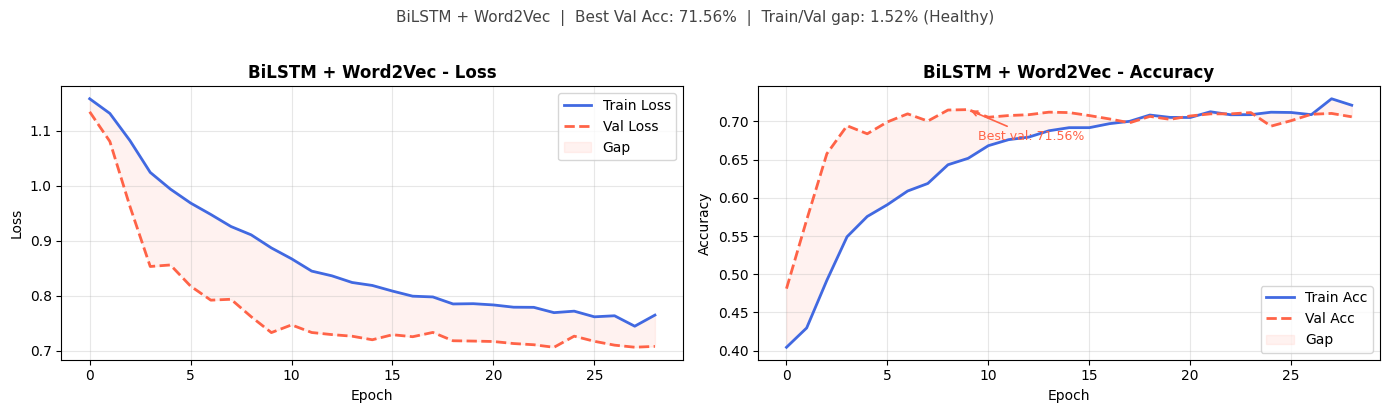


Prediction distribution : {'Negative': 564, 'Neutral': 403, 'Positive': 833}

  BiLSTM + Word2Vec - Test Accuracy: 71.67%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.76      0.78       600
     Neutral       0.33      0.45      0.38       300
    Positive       0.84      0.78      0.81       900

    accuracy                           0.72      1800
   macro avg       0.66      0.66      0.66      1800
weighted avg       0.74      0.72      0.73      1800



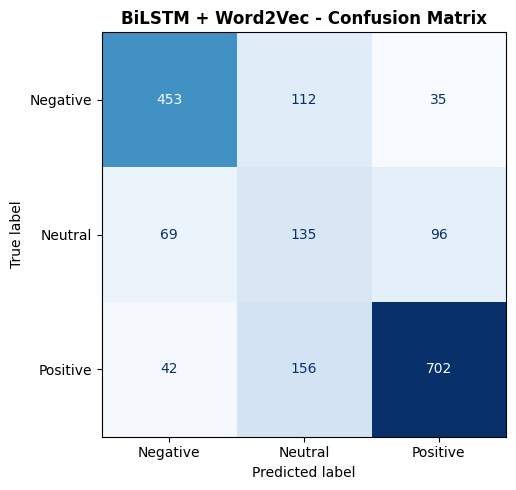

In [ ]:
plot_history(lstm_word2vec_history, 'BiLSTM + Word2Vec')
lstm_word2vec_acc, lstm_word2vec_preds = evaluate_model(
    lstm_word2vec_model, X_test_pad, y_test, 'BiLSTM + Word2Vec')

---
## 9. Comparative Analysis

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'BiLSTM (Trainable Emb)',
        'BiLSTM + Word2Vec'
    ],
    'Test Accuracy (%)': [
        round(rnn_acc              * 100, 2),
        round(lstm_acc             * 100, 2),
        round(lstm_word2vec_acc    * 100, 2)
    ],
    'Training Time (s)': [
        round(rnn_train_time,              1),
        round(lstm_train_time,             1),
        round(lstm_word2vec_train_time,    1)
    ]
})

print("\n" + "=" * 65)
print("              MODEL COMPARISON SUMMARY")
print("=" * 65)
print(results.to_string(index=False))
print("\nNote: Simple RNN and BiLSTM (Trainable) use EMBED_DIM=64; BiLSTM+Word2Vec uses WORD2VEC_DIM=100.")
print("Embedding dimension differs, giving Word2Vec model a slight capacity advantage.")


              MODEL COMPARISON SUMMARY
                 Model  Test Accuracy (%)  Training Time (s)
            Simple RNN              71.33              525.8
BiLSTM (Trainable Emb)              72.06             1668.0
     BiLSTM + Word2Vec              71.67             2066.1

Note: Simple RNN and BiLSTM (Trainable) use EMBED_DIM=64; BiLSTM+Word2Vec uses WORD2VEC_DIM=100.
Embedding dimension differs, giving Word2Vec model a slight capacity advantage.


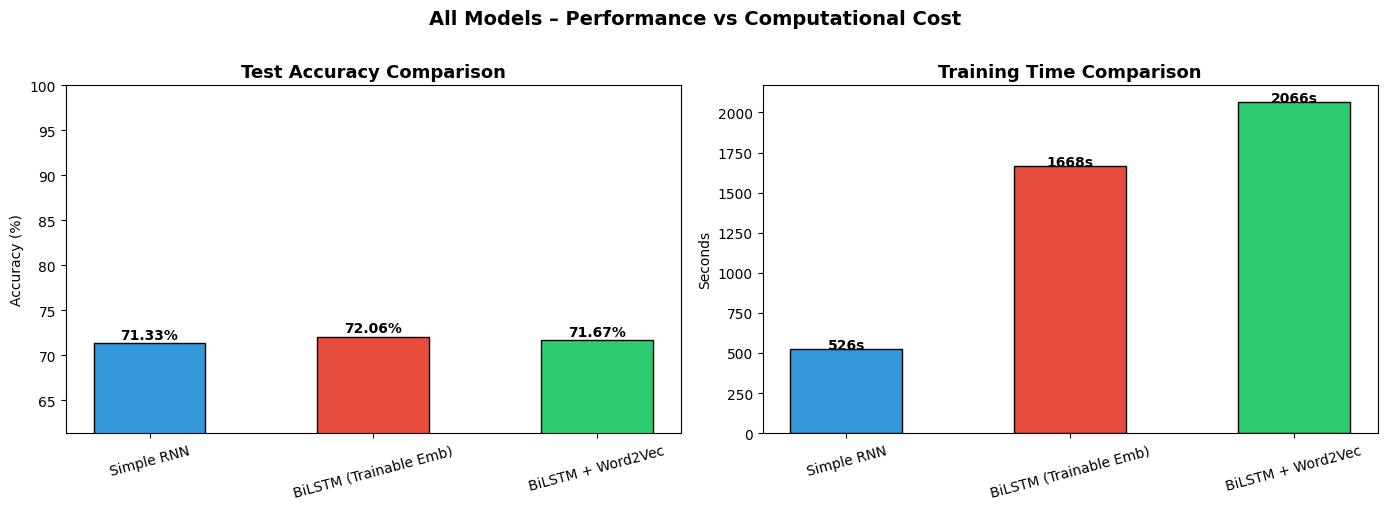

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Accuracy
axes[0].bar(results['Model'], results['Test Accuracy (%)'],
            color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
min_acc = min(results['Test Accuracy (%)'])
axes[0].set_ylim([max(0, min_acc - 10), 100])  # dynamic floor shows differences clearly
for i, v in enumerate(results['Test Accuracy (%)']):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Training time
axes[1].bar(results['Model'], results['Training Time (s)'],
            color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seconds')
for i, v in enumerate(results['Training Time (s)']):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('All Models – Performance vs Computational Cost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

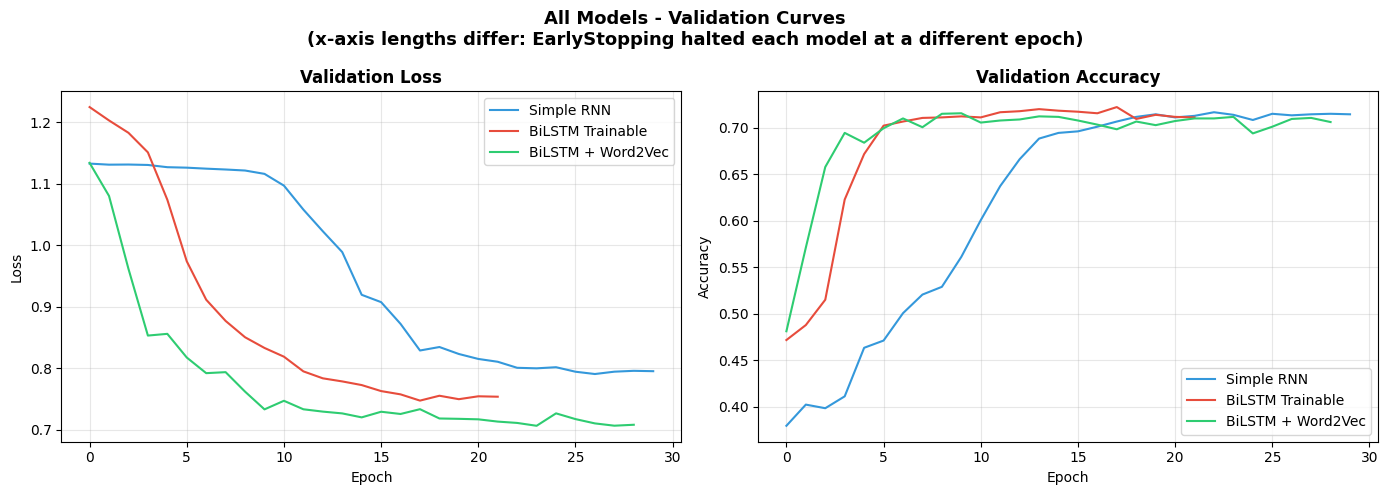

In [ ]:
# Overlay validation curves for all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_histories = [
    (rnn_history,             'Simple RNN',        '#3498db'),
    (lstm_history,            'BiLSTM Trainable',  '#e74c3c'),
    (lstm_word2vec_history,   'BiLSTM + Word2Vec', '#2ecc71'),
]

for hist, name, col in model_histories:
    axes[0].plot(hist.history['val_loss'],     label=name, color=col)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=col)

for ax, title, ylabel in zip(
        axes,
        ['Validation Loss', 'Validation Accuracy'],
        ['Loss', 'Accuracy']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('All Models - Validation Curves\n(x-axis lengths differ: EarlyStopping halted each model at a different epoch)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_validation_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Error Analysis

In [ ]:
print("=" * 60)
print("ERROR ANALYSIS  -  BiLSTM + Word2Vec (Best Model)")
print("=" * 60)

wrong_mask    = (lstm_word2vec_preds != y_test)
wrong_indices = np.where(wrong_mask)[0]

print(f"\nTotal misclassified : {len(wrong_indices)} / {len(y_test)} "
      f"({len(wrong_indices)/len(y_test)*100:.1f}%)")

print("\n--- 3 Sample Misclassified Reviews ---")
for rank, idx in enumerate(wrong_indices[:3], 1):
    true_lbl = label_names[y_test[idx]]
    pred_lbl = label_names[lstm_word2vec_preds[idx]]
    print(f"\n[{rank}] True: {true_lbl}  |  Predicted: {pred_lbl}")
    print(f"    Review : {X_test_raw[idx][:200]} ...")

ERROR ANALYSIS  -  BiLSTM + Word2Vec (Best Model)

Total misclassified : 510 / 1800 (28.3%)

--- 3 Sample Misclassified Reviews ---

[1] True: Neutral  |  Predicted: Positive
    Review : enjoyed short novella character not well developed but storyline goodthis only story jacqueline diamond not three book rick rebecca best friend becca getting married rick man honor alway done right th ...

[2] True: Negative  |  Predicted: Neutral
    Review : book very slow read think drug distorted view mother thought only choice left murder ...

[3] True: Positive  |  Predicted: Neutral
    Review : reviewer done great job summarizing book not repeat summary nervous purchasing book based idea short story not price issue author set very low price compensated length book little leery basic limitati ...


In [ ]:
# Per-class error breakdown
print("Per-class error breakdown:")
for cls in range(NUM_CLASSES):
    mask   = y_test == cls
    errors = np.sum(lstm_word2vec_preds[mask] != y_test[mask])
    total  = np.sum(mask)
    print(f"  {label_names[cls]:10s}: {errors}/{total} errors "
          f"({errors/total*100:.1f}%)")

print("""
Observations:
  1. Neutral (3-star) reviews are hardest because their vocabulary overlaps with both extremes.
  2. Short reviews (< 5 cleaned words) carry insufficient context for the model.
  3. Sarcastic or mixed-opinion reviews can mislead the model.

Suggested improvements:
  - Use stronger pretrained embeddings or transformer models for richer context.
  - Oversample the Neutral class or apply focal loss for better class balance.
  - Tune MAX_LEN, vocabulary size, BiLSTM units, and dropout with validation data.
""")

Per-class error breakdown:
  Negative  : 147/600 errors (24.5%)
  Neutral   : 165/300 errors (55.0%)
  Positive  : 198/900 errors (22.0%)

Observations:
  1. Neutral (3-star) reviews are hardest because their vocabulary overlaps with both extremes.
  2. Short reviews (< 5 cleaned words) carry insufficient context for the model.
  3. Sarcastic or mixed-opinion reviews can mislead the model.

Suggested improvements:
  - Use stronger pretrained embeddings or transformer models for richer context.
  - Oversample the Neutral class or apply focal loss for better class balance.
  - Tune MAX_LEN, vocabulary size, BiLSTM units, and dropout with validation data.



---
## 11. Save the Best Model

In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample'
os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, 'bilstm_word2vec_sentiment_model.keras')
lstm_word2vec_model.save(SAVE_PATH)
print(f"Model saved -> {SAVE_PATH}")

# To reload in a new session:
# loaded_model = tf.keras.models.load_model(SAVE_PATH)
# print("Loaded successfully.")

Model saved -> /content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample/bilstm_word2vec_sentiment_model.keras


In [ ]:
import pickle
import os

SAVE_DIR = '/content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample'
os.makedirs(SAVE_DIR, exist_ok=True)

TOKENIZER_SAVE_PATH = os.path.join(SAVE_DIR, 'tokenizer.pickle')

with open(TOKENIZER_SAVE_PATH, 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Tokenizer saved -> {TOKENIZER_SAVE_PATH}")

Tokenizer saved -> /content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample/tokenizer.pickle


---
## 12. Real-Time Prediction GUI (Gradio)

In [3]:
# Import necessary libraries for standalone execution
# Ensure contractions is installed for the Gradio app environment
!pip install contractions

import gradio as gr
import tensorflow as tf
import numpy as np
import pickle
import re
import string
import os
import contractions
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Ensure NLTK data is downloaded for the Gradio app environment
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# These values must match the preprocessing/training section above.
MAX_LEN = 187
label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

FULL_STOP_WORDS = set(stopwords.words('english'))
KEEP_WORDS = {'not','no','never','nor','neither','without',
              'very','too','only','but','however','although'}
STOP_WORDS = FULL_STOP_WORDS - KEEP_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a raw book review."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)


SAVE_DIR = '/content/drive/MyDrive/Herald/6th Sem Big Data/Coursework/new Notebook/sample'
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'bilstm_word2vec_sentiment_model.keras')
TOKENIZER_SAVE_PATH = os.path.join(SAVE_DIR, 'tokenizer.pickle')

loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
with open(TOKENIZER_SAVE_PATH, 'rb') as handle:
    loaded_tokenizer = pickle.load(handle)


def predict_sentiment(review_text):
    """Predict sentiment for a user-entered book review."""
    cleaned_text = clean_text(review_text)
    sequence = loaded_tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN,
                                    padding='post', truncating='post')

    prediction_proba = loaded_model.predict(padded_sequence, verbose=0)[0]
    predicted_class = int(np.argmax(prediction_proba))
    sentiment = label_names[predicted_class]
    confidence = float(prediction_proba[predicted_class])

    probabilities = {
        label_names[i]: float(prediction_proba[i])
        for i in range(len(label_names))
    }

    return sentiment, confidence, probabilities


iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=6, placeholder="Enter a book review here..."),
    outputs=[
        gr.Textbox(label="Predicted sentiment"),
        gr.Number(label="Confidence"),
        gr.Label(label="Class probabilities")
    ],
    title="Book Review Sentiment Classifier",
    description="BiLSTM + Word2Vec sentiment classifier for book reviews."
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d721e23945433e5c23.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
